## Set up simulation

### Data

  **Cases**
- Start date: 2020
- End date: June 2023 

*Cases by catchment end date:

  **Wastewater**: 
- Start date: February 2021 (2/24/21)
- End date; November 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
print(smf)
from pathlib import Path
import covasim as cv

#print(cv.__file__)
#print(hasattr(cv, "Sim"))
print(cv.Sim)

<module 'statsmodels.formula.api' from '/storage/hcraddock/mamba/envs/covasim/lib/python3.10/site-packages/statsmodels/formula/api.py'>
Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM
<class 'covasim.sim.Sim'>


In [3]:
DATA_ROOT = Path.home() / "GitHub"
WW_REPO = DATA_ROOT / "SARS-CoV-2_WasteWater_San-Diego"
CASES_REPO = DATA_ROOT / "lone_pine" / "resources"

In [4]:
OUT = Path.home() / "GitHub" / "covasim_fit_data"     # same folder you saved to

### Data

In [4]:
#CASE DATA
cases = pd.read_csv(CASES_REPO/ "cases.csv")
zips = pd.read_csv(WW_REPO / "Zipcodes.csv")

#WASTEWATER DATA
ww_pl = pd.read_csv(WW_REPO / "PointLoma_sewage_qPCR.csv")

In [5]:
print(cases.shape)
cases.head()

(129059, 7)


,updatedate,ziptext,case_count,new_cases,days_past,population,catchment
0,2020-03-31,91902.0,0.0,0.0,1179,17653,PointLoma
1,2020-03-31,92113.0,0.0,0.0,1179,56066,PointLoma
2,2020-03-31,92111.0,0.0,0.0,1179,45096,PointLoma
3,2020-03-31,92110.0,0.0,0.0,1179,25341,PointLoma
4,2020-03-31,92109.0,0.0,0.0,1179,45787,PointLoma


## 2. Format Case data
- Untangle as A mix of weekly + daily 

### I. Format Point Loma data

In [6]:
df_cases_pl_total = cases[cases["catchment"] == "PointLoma"].copy()  # Point Loma zips only
df_cases_pl_total["updatedate"] = pd.to_datetime(df_cases_pl_total["updatedate"])
df_cases_pl_total.head(2)
#Note different zip codes in point loma

,updatedate,ziptext,case_count,new_cases,days_past,population,catchment
0,2020-03-31,91902.0,0.0,0.0,1179,17653,PointLoma
1,2020-03-31,92113.0,0.0,0.0,1179,56066,PointLoma


#### ii. Get Catchment Population

In [7]:
#Get catchment population
CATCHMENT_POP = df_cases_pl_total.groupby("ziptext")["population"].max().sum()

#Check Catchment population: one value per zip, not summed over all dates
print(df_cases_pl_total.groupby("ziptext")["population"].nunique().max(), "max distinct populations per zip (should be 1)")
print("Catchment population:", CATCHMENT_POP)

1 max distinct populations per zip (should be 1)
Catchment population: 2116170


#### iii. Aggregate one row per date

In [8]:
#Many point Loma cases so aggregate all into one row per date
df_cases_pl = (df_cases_pl_total.groupby("updatedate", as_index=False)   # one row per date
                             .agg(new_cases=("new_cases", "sum")))
df_cases_pl.head(2)

,updatedate,new_cases
0,2020-03-31,0.0
1,2020-04-01,87.0


#### iv. Add daily rate per 100k

In [9]:
### Add daily rate per 100,000
df_cases_pl["new_cases_per_100k"] = (df_cases_pl["new_cases"] / CATCHMENT_POP)*100_000
df_cases_pl.head(2)

,updatedate,new_cases,new_cases_per_100k
0,2020-03-31,0.0,0.000000
1,2020-04-01,87.0,4.111201


### II. Aggregate Point Loma data across zip codes so one value per date
- Catchement population: 2,116,170

In [11]:
# One row per date, summed across Point Loma zips
df_cases_pl = (df_cases_pl_total.groupby("updatedate", as_index=False)
                 .agg(case_count=("case_count", "sum"),
                      new_cases=("new_cases", "sum"),
                      n_zips=("ziptext", "nunique")))

In [12]:
### Add daily rate per 100,000
df_cases_pl["new_cases_per_100k"] = (df_cases_pl["new_cases"] / CATCHMENT_POP)*100_000

In [13]:
print(df_cases_pl["updatedate"].dtype)   # expect datetime64[ns])
df_cases_pl["updatedate"].nunique()

datetime64[ns]


1174

In [14]:
df_cases_pl.head()

,updatedate,case_count,new_cases,n_zips,new_cases_per_100k
0,2020-03-31,0.0,0.0,55,0.000000
1,2020-04-01,87.0,87.0,55,4.111201
2,2020-04-02,214.0,127.0,56,6.001408
3,2020-04-03,289.0,75.0,57,3.544139
4,2020-04-04,343.0,54.0,57,2.551780


In [43]:
z = df_cases_pl_total[df_cases_pl_total["updatedate"] > "2021-06-28"].copy()
z["nc"] = z["new_cases"].round(4)
z["step"] = z.groupby("ziptext")["nc"].diff().fillna(1) != 0
print(z.loc[z["step"], "updatedate"].dt.day_name().value_counts())


updatedate
Wednesday    3166
Monday       1347
Tuesday      1334
Sunday        450
Thursday      121
Name: count, dtype: int64


## Part 2: Split data into Daily and Weekly
- Daily data reporting: Ends 06-08-2021
- Weeky data: after 06-2021 (including Omicron wave in November 2021)

### i. Daily data up to 06-2021

In [15]:
#Daily data 
DAILY_REPORTING_SWITCH = pd.Timestamp("2021-06-28")   # last day of daily reporting (from the lab's script)

# ---- Daily table: true daily values, before the switch ----
df_pl_daily = (df_cases_pl[df_cases_pl["updatedate"] <= DAILY_REPORTING_SWITCH]
               .reset_index(drop=True))
df_pl_daily.head(2)

,updatedate,case_count,new_cases,n_zips,new_cases_per_100k
0,2020-03-31,0.0,0.0,55,0.000000
1,2020-04-01,87.0,87.0,55,4.111201


### ii. Weekly data after 06-2021

#### Step 1: Find weekly switch points

In [ ]:
# ---- Weekly table: one row per reporting week, after the switch ----
cases_after_switch = df_cases_pl[df_cases_pl["updatedate"] > DAILY_REPORTING_SWITCH].reset_index(drop=True)
cases_after_switch.tail(30)

In [30]:
#LOCATION WHERE DATE/WEEK STEPS 
change_from_prev_day = cases_after_switch["new_cases"].diff()
is_new_week = change_from_prev_day.fillna(1).abs() > 1e-6   # a real change, not float noise
week_number = is_new_week.cumsum()
cases_after_switch["week_number"] = week_number
cases_after_switch.head()

,updatedate,case_count,new_cases,n_zips,new_cases_per_100k,week_number
0,2021-06-29,177147.000000,9.000000,62,0.425297,1
1,2021-06-30,177260.142857,113.142857,62,5.346586,2
2,2021-07-01,177373.285714,113.142857,62,5.346586,2
3,2021-07-02,177486.428571,113.142857,62,5.346586,2
4,2021-07-03,177599.571429,113.142857,62,5.346586,2


In [33]:
print(cases_after_switch['week_number'].nunique())

122


In [31]:
### Check
chk = (cases_after_switch.groupby("week_number")
         .agg(n_days=("updatedate", "size"),
              daily_avg=("new_cases", "first"),
              summed=("new_cases", "sum")))
chk["x7"] = chk["daily_avg"] * 7
chk["match"] = (chk["summed"] - chk["x7"]).abs() < 1e-3
print(chk[chk["n_days"] == 7]["match"].all())   # expect True
print(chk[~chk["match"]].head())                # the blocks where ×7 and the sum disagree

True
             n_days    daily_avg       summed       x7  match
week_number                                                  
1                 1     9.000000     9.000000     63.0  False
27                1  1597.000000  1597.000000  11179.0  False
28                6  1648.285714  9889.714286  11538.0  False
39                5   288.428571  1442.142857   2019.0  False
40                2   290.000000   580.000000   2030.0  False


#### Step 2: Aggregate daily cases to weeks

- After the switch, each weekly total is repeated for 7 days (a staircase).
- `week_number` increases by 1 each time the value changes, so each step gets its own label.
- Group by `week_number` to get one row per week.
- `week_start` / `week_end`: first and last date of the week.
- `n_days`: days in the week (7 = full week).
- `cases_wk_avg`: weekly total ÷ 7, i.e. average cases per day.

In [35]:
# Anchor the weekly grid on the first clean block (week 2), taken from the data
grid_start = cases_after_switch.loc[cases_after_switch["week_number"] == 2, "updatedate"].min()
print("Grid starts:", grid_start.date(), grid_start.day_name())

d = cases_after_switch[cases_after_switch["updatedate"] >= grid_start].copy()
d["nc_round"] = d["new_cases"].round(4)

# Renamed so it doesn't clash with the existing step-detection column
d["week_number_grid"] = (d["updatedate"] - grid_start).dt.days // 7 + 1

df_pl_weekly = (d.groupby("week_number_grid")
                  .agg(week_start=("updatedate", "min"),
                       week_end=("updatedate", "max"),
                       n_days=("updatedate", "size"),
                       n_distinct_values=("nc_round", "nunique"),
                       weekly_total=("new_cases", "sum"))
                  .reset_index()
                  .rename(columns={"week_number_grid": "week_number"}))

df_pl_weekly["week_mid"] = df_pl_weekly["week_start"] + pd.Timedelta(days=3)
df_pl_weekly["weekly_total_per_100k"] = df_pl_weekly["weekly_total"] * 100_000 / CATCHMENT_POP

# Keep full weeks only (drops the partial last week)
df_pl_weekly = df_pl_weekly[df_pl_weekly["n_days"] == 7].reset_index(drop=True)

print(df_pl_weekly.shape)
df_pl_weekly.head()

Grid starts: 2021-06-30 Wednesday
(102, 8)


,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k
0,1,2021-06-30,2021-07-06,7,1,792.0,2021-07-03,37.426105
1,2,2021-07-07,2021-07-13,7,1,1394.0,2021-07-10,65.873725
2,3,2021-07-14,2021-07-20,7,1,2157.0,2021-07-17,101.929429
3,4,2021-07-21,2021-07-27,7,1,3626.0,2021-07-24,171.347293
4,5,2021-07-28,2021-08-03,7,1,4613.0,2021-07-31,217.988158


In [36]:
print(df_pl_weekly['week_number'].nunique())

102


## QED - Data created

In [40]:
#### Check omicron
# Omicron dates
FIT_START = pd.Timestamp("2021-11-15")
FIT_END   = pd.Timestamp("2022-03-01")
om = df_pl_weekly[(df_pl_weekly["week_start"] >= FIT_START) & (df_pl_weekly["week_end"] <= FIT_END)]
print(len(om))
print(om["n_distinct_values"].value_counts())

15
n_distinct_values
1    14
2     1
Name: count, dtype: int64


In [37]:
print((len(cases_after_switch) - 1) / 7)      # 102.57 -> 102 full weeks + 4 days
print(chk["n_days"].value_counts())            # how many blocks are not 7 days
print(df_pl_weekly["week_end"].max().date())   # expect 2023-06-13

102.57142857142857
n_days
7     78
6     11
2     10
1      9
5      7
4      3
3      2
14     1
11     1
Name: count, dtype: int64
2023-06-13


## Plot

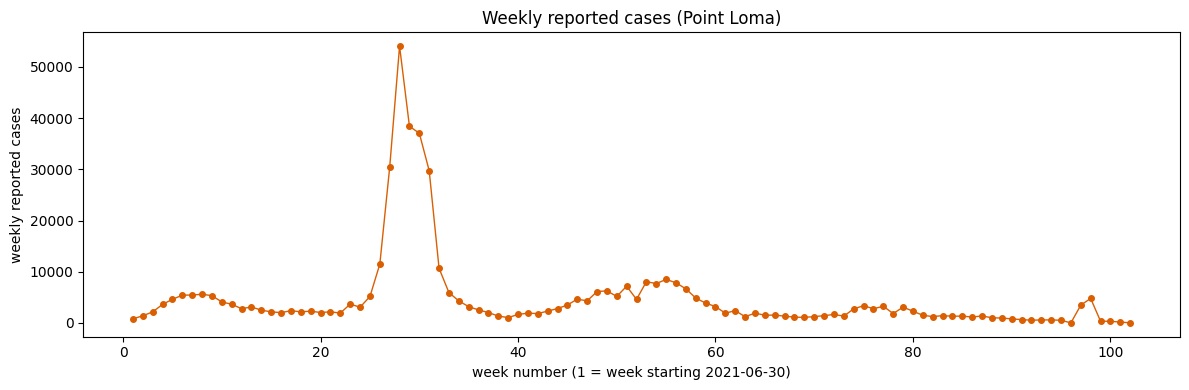

In [46]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_pl_weekly["week_number"], df_pl_weekly["weekly_total"], "o-", ms=4, lw=1, color="#D95F02")
ax.set_xlabel("week number (1 = week starting 2021-06-30)")
ax.set_ylabel("weekly reported cases")
ax.set_title("Weekly reported cases (Point Loma)")
plt.tight_layout()
plt.show()

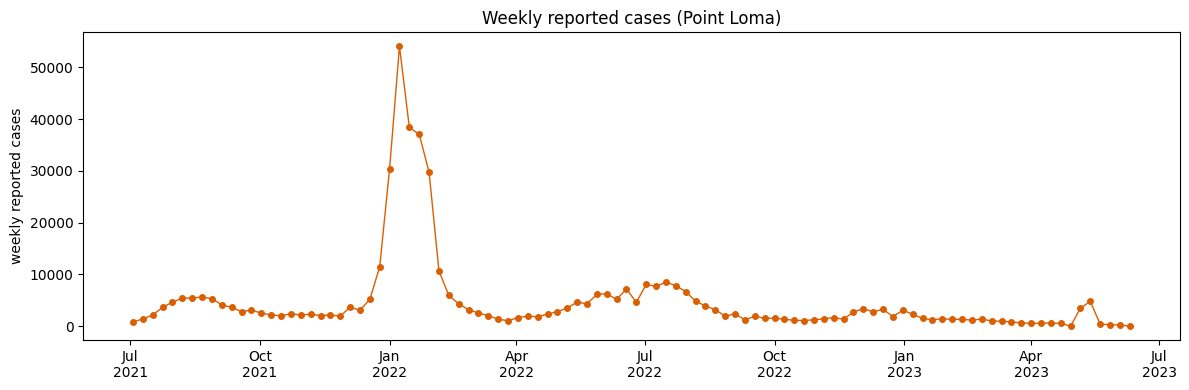

In [47]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_pl_weekly["week_mid"], df_pl_weekly["weekly_total"], "o-", ms=4, lw=1, color="#D95F02")

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 3)))   # Jan, Apr, Jul, Oct
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.set_ylabel("weekly reported cases")
ax.set_title("Weekly reported cases (Point Loma)")
plt.tight_layout()
plt.show()

## SAVE

In [5]:
print(Path.cwd())     # where the notebook is running
print(OUT.resolve())  # where the data will be saved

/storage/hcraddock/GitHub/covasim4wastewater/docs/tutorials/modeling
/storage/hcraddock/GitHub/covasim_fit_data


In [48]:
df_pl_weekly.to_pickle(OUT / "df_cases_weekly_pl.pkl")

In [49]:
df_pl_weekly.to_csv(OUT / "df_cases_weekly_pl.csv", index=False)

In [ ]:
ww_pl.to_pickle(OUT / "pl_wastewater.pkl")
ww_pl.to_csv(OUT / "pl_wastewater.csv", index=False)

In [50]:
print((OUT / "df_cases_weekly_pl.pkl").resolve())
print((OUT / "df_cases_weekly_pl.pkl").exists())   # True if it saved

/storage/hcraddock/GitHub/covasim_fit_data/df_cases_weekly_pl.pkl
True


# QED

## Reload & Format & Re-save

In [6]:
df_pl_ww = pd.read_pickle(OUT / "df_ww_pl.pkl")
print(df_pl_ww.dtypes)   
df_pl_ww.head()

Sample_Date                 object
Mean viral gene copies/L     int64
dtype: object


,Sample_Date,Mean viral gene copies/L
0,2/24/21,681730
1,2/28/21,943877
2,3/1/21,1034196
3,3/3/21,1918221
4,3/7/21,770022


In [7]:
#Rename
df_pl_ww = df_pl_ww.rename(columns={"Mean viral gene copies/L": "ww_copies_per_L"})

In [8]:
## Convert to date-type
df_pl_ww["Sample_Date"] = pd.to_datetime(df_pl_ww["Sample_Date"], format="%m/%d/%y")

In [10]:
df_pl_ww.to_pickle(OUT / "df_ww_pl.pkl")

# QED - RESAVED WASTEATER

## Omicron wave

In [39]:
# Omicron dates
FIT_START = pd.Timestamp("2021-11-15")
FIT_END   = pd.Timestamp("2022-03-01")

In [ ]:
# Step 1: pick the column, with the date as the index
df_cases_pl_omc = df_pl_weekly.set_index("updatedate")["new_cases_per_100k"]

df_pl_weekly

In [41]:
df_cases_pl.tail()

,updatedate,case_count,new_cases,n_zips,new_cases_per_100k
1169,2023-06-13,654270.142857,0.714286,62,0.033754
1170,2023-06-14,654270.857143,0.714286,62,0.033754
1171,2023-06-15,654271.571429,0.714286,62,0.033754
1172,2023-06-16,654272.285714,0.714286,62,0.033754
1173,2023-06-17,654273.000000,0.714286,62,0.033754


In [50]:
w = df_cases_pl.set_index("updatedate").loc[FIT_START:FIT_END]
print(len(w), "days in window")
print("zero days in window:", (w["new_cases"] == 0).sum())
print("non-integer share (raw counts):", (w["new_cases"].round() != w["new_cases"]).mean())
print(w.loc[w["new_cases"] == 0].index.date)

107 days in window
zero days in window: 0
non-integer share (raw counts): 1.0
[]


In [51]:
# Step 2: Cases omicron
cases_omicicron_pl = df_cases_pl.set_index("updatedate")["new_cases"].loc[FIT_START:FIT_END]

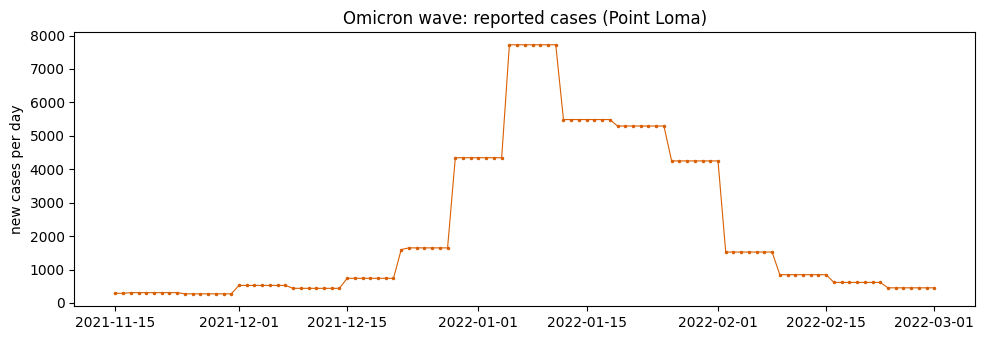

In [52]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(cases_omicicron_pl.index, cases_omicicron_pl, ".-", ms=3, lw=0.8, color="#D95F02")
ax.set_ylabel("new cases per day")
ax.set_title("Omicron wave: reported cases (Point Loma)")
plt.tight_layout()
plt.show()

In [53]:
cases_omicicron_pl

updatedate
2021-11-15    289.285714
2021-11-16    289.285714
2021-11-17    308.857143
2021-11-18    308.857143
2021-11-19    308.857143
                 ...    
2022-02-25    453.000000
2022-02-26    453.000000
2022-02-27    453.000000
2022-02-28    453.000000
2022-03-01    453.000000
Name: new_cases, Length: 107, dtype: float64

In [ ]:



# Wastewater: only the days that have a measurement
ww_obs = (ww.set_index("date")["ww_copies_per_L"]
            .sort_index()
            .loc[FIT_START:FIT_END])

print(len(cases_obs), "case days;", len(ww_obs), "wastewater days")
print(cases_obs.describe())

## Simulation

In [ ]:

POP_SIZE = 50_000
POP_SCALE = CATCHMENT_POP / POP_SIZE        # sim agents represent the real catchment population
LEAD_IN = 21                                 # days of warm-up before the fit window

sim = cv.Sim(
    pop_size=POP_SIZE,
    pop_scale=POP_SCALE,
    pop_type='hybrid',
    
    location='usa',                          # see note below
    pop_infected=500,
    n_imports=0,
    start_day=FIT_START - pd.Timedelta(days=LEAD_IN),
    end_day=FIT_END,
    interventions=[testing],
    verbose=0,
)
sim.run()

df = extract_wastewater_regression_data(sim)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# Cases in the same units as the data
df["cases_per_100k"] = df["cases"] / CATCHMENT_POP * 100_000
print(df.head())